<a href="https://colab.research.google.com/github/BrunoCamposIME/Artigo-Modelo-Computacional/blob/main/Modelo_Computacional_Artigo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Programa 01

In [13]:
# ============================================================
#                      PROGRAMA 01
#      Sistema de Seleção e Gerenciamento de Fornecedores
# ============================================================

import csv
from dataclasses import dataclass
from typing import List, Optional
import os
import platform
import subprocess

# -----------------------------
# MODELOS DE DADOS
# -----------------------------

@dataclass
class Fornecedor:
    fonte: str
    material: str
    custo_aquisicao: float  # R$/ton
    distancia_rodo: Optional[float]  # km
    distancia_ferro: Optional[float]  # km
    km_ferro: float  # km (obrigatório)

@dataclass
class ResultadoFornecedor:
    fornecedor: Fornecedor
    custo_total: float  # R$/ton
    custo_transporte: float  # R$/ton
    modal: str  # não exibido

# -----------------------------
# BANCOS DE DADOS
# -----------------------------

DB_FORNEC = "fornecedores_db.csv"
DB_CUSTOS = "custos_transporte.csv"

# -----------------------------
# BANCO DE FORNECEDORES
# -----------------------------

def inicializar_db_fornecedores():
    if not os.path.exists(DB_FORNEC):
        with open(DB_FORNEC, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f, delimiter=";")
            writer.writerow([
                "Fonte", "Tipo de Material", "Custo de Aquisição (R$/ton)",
                "Distância Rodoviária (km)", "Distância Ferroviária (km)", "KM Ferroviária"
            ])

def carregar_fornecedores() -> List[Fornecedor]:
    inicializar_db_fornecedores()
    fornecedores = []
    with open(DB_FORNEC, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter=";")
        for row in reader:
            fornecedores.append(Fornecedor(
                fonte=row["Fonte"],
                material=row["Tipo de Material"],
                custo_aquisicao=float(row["Custo de Aquisição (R$/ton)"]),
                distancia_rodo=float(row["Distância Rodoviária (km)"]) if row["Distância Rodoviária (km)"] else None,
                distancia_ferro=float(row["Distância Ferroviária (km)"]) if row["Distância Ferroviária (km)"] else None,
                km_ferro=float(row["KM Ferroviária"])
            ))
    return fornecedores

def fornecedor_existe(fornecedores, fonte, material):
    fonte = fonte.lower().strip()
    material = material.lower().strip()
    for f in fornecedores:
        if f.fonte.lower() == fonte and f.material.lower() == material:
            return True
    return False

def salvar_fornecedor(f: Fornecedor):
    with open(DB_FORNEC, "a", newline="", encoding="utf-8") as f_out:
        writer = csv.writer(f_out, delimiter=";")
        writer.writerow([
            f.fonte, f.material, f.custo_aquisicao,
            f.distancia_rodo if f.distancia_rodo is not None else "",
            f.distancia_ferro if f.distancia_ferro is not None else "",
            f.km_ferro
        ])

def salvar_todos_fornecedores(fornecedores: List[Fornecedor]):
    with open(DB_FORNEC, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f, delimiter=";")
        writer.writerow([
            "Fonte", "Tipo de Material", "Custo de Aquisição (R$/ton)",
            "Distância Rodoviária (km)", "Distância Ferroviária (km)", "KM Ferroviária"
        ])
        for fnd in fornecedores:
            writer.writerow([
                fnd.fonte, fnd.material, fnd.custo_aquisicao,
                fnd.distancia_rodo if fnd.distancia_rodo is not None else "",
                fnd.distancia_ferro if fnd.distancia_ferro is not None else "",
                fnd.km_ferro
            ])

# -----------------------------
# BANCO DE CUSTOS DE TRANSPORTE
# -----------------------------

def inicializar_db_custos():
    if not os.path.exists(DB_CUSTOS):
        with open(DB_CUSTOS, "w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f, delimiter=";")
            writer.writerow(["Custo Rodoviário (R$/ton·km)", "Custo Ferroviário (R$/ton·km)"])
            writer.writerow([0.0, 0.0])

def carregar_custos():
    inicializar_db_custos()
    with open(DB_CUSTOS, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter=";")
        row = next(reader)
        return float(row["Custo Rodoviário (R$/ton·km)"]), float(row["Custo Ferroviário (R$/ton·km)"])

def salvar_custos(c_rodo, c_ferro):
    with open(DB_CUSTOS, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f, delimiter=";")
        writer.writerow(["Custo Rodoviário (R$/ton·km)", "Custo Ferroviário (R$/ton·km)"])
        writer.writerow([c_rodo, c_ferro])

# -----------------------------
# FUNÇÕES AUXILIARES
# -----------------------------

def ler_float(msg):
    v = input(msg).strip()
    if v == "":
        return None
    return float(v.replace(",", "."))

def ler_km_ferro():
    while True:
        v = input("KM Ferroviária (obrigatório, entre 108 e 496): ").strip()
        try:
            km = float(v.replace(",", "."))
            if 108 <= km <= 496:
                return km
            else:
                print("Valor inválido. O KM deve estar entre 108 e 496.")
        except:
            print("Entrada inválida. Digite um número válido.")

def distancia_ferro_total(f: Fornecedor, km_ocorrencia: float) -> float:
    base = f.distancia_ferro if f.distancia_ferro is not None else 0
    return base + abs(f.km_ferro - km_ocorrencia)

def abrir_arquivo(filepath):
    sistema = platform.system()
    if sistema == "Windows":
        os.startfile(filepath)
    elif sistema == "Darwin":
        subprocess.call(["open", filepath])
    else:
        subprocess.call(["xdg-open", filepath])

# -----------------------------
# CÁLCULO DO TOP 3
# -----------------------------

def calcular_top3(km_ocorrencia, materiais, fornecedores, custo_ton_km_rodo, custo_ton_km_ferro):
    resultados = []

    for f in fornecedores:
        if f.material.lower() not in materiais:
            continue

        dist_ferro = distancia_ferro_total(f, km_ocorrencia)
        custo_ferro = dist_ferro * custo_ton_km_ferro
        custo_rodo = f.distancia_rodo * custo_ton_km_rodo if f.distancia_rodo is not None else 0

        custo_trans = custo_ferro + custo_rodo
        custo_total = f.custo_aquisicao + custo_trans

        resultados.append(ResultadoFornecedor(
            fornecedor=f,
            custo_total=round(custo_total, 2),
            custo_transporte=round(custo_trans, 2),
            modal="ferrovia + rodovia"
        ))

    resultados.sort(key=lambda r: r.custo_total)
    return resultados[:3]

# -----------------------------
# EXPORTAÇÃO
# -----------------------------

def exportar_resultados(top3: List[ResultadoFornecedor]):
    filename = "resultado_top3.csv"

    with open(filename, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f, delimiter=";")
        writer.writerow(["Fornecedor", "Material", "Custo Transporte (R$/ton)", "Custo Total (R$/ton)"])
        for r in top3:
            writer.writerow([
                r.fornecedor.fonte,
                r.fornecedor.material,
                r.custo_transporte,
                r.custo_total
            ])

    print(f"\nArquivo '{filename}' exportado com sucesso.")
    abrir_arquivo(filename)

# -----------------------------
# EDITAR FORNECEDOR
# -----------------------------

def editar_fornecedor(fornecedores):
    print("\n=== EDITAR FORNECEDOR ===")
    for i, f in enumerate(fornecedores, start=1):
        print(f"{i} - {f.fonte} | {f.material}")

    idx = int(input("\nEscolha o número do fornecedor para editar: ")) - 1
    f = fornecedores[idx]

    print("\nDeixe em branco para manter o valor atual.\n")

    nova_fonte = input(f"Fonte [{f.fonte}]: ").strip() or f.fonte
    novo_material = input(f"Material [{f.material}]: ").strip() or f.material

    novo_custo = input(f"Custo aquisição (R$/ton) [{f.custo_aquisicao}]: ").strip()
    novo_custo = float(novo_custo.replace(",", ".")) if novo_custo else f.custo_aquisicao

    nova_rodo = input(f"Distância rodoviária (km) [{f.distancia_rodo}]: ").strip()
    nova_rodo = float(nova_rodo.replace(",", ".")) if nova_rodo else f.distancia_rodo

    nova_ferro = input(f"Distância ferroviária (km) [{f.distancia_ferro}]: ").strip()
    nova_ferro = float(nova_ferro.replace(",", ".")) if nova_ferro else f.distancia_ferro

    novo_km = input(f"KM ferroviária [{f.km_ferro}]: ").strip()
    novo_km = float(novo_km.replace(",", ".")) if novo_km else f.km_ferro

    # Verificar duplicidade ao editar
    if fornecedor_existe(fornecedores, nova_fonte, novo_material) and \
       (nova_fonte != f.fonte or novo_material != f.material):
        print("\nERRO: Já existe um fornecedor com essa combinação de Fonte + Material.")
        return

    fornecedores[idx] = Fornecedor(
        nova_fonte, novo_material, novo_custo, nova_rodo, nova_ferro, novo_km
    )

    salvar_todos_fornecedores(fornecedores)
    print("\nFornecedor atualizado com sucesso!")

# -----------------------------
# PROGRAMA PRINCIPAL
# -----------------------------

def main():

    while True:
        print("\n=== PROGRAMA 01 — MENU PRINCIPAL ===")
        print("1 - Revisar fornecedores cadastrados")
        print("2 - Cadastrar novo fornecedor")
        print("3 - Excluir fornecedor")
        print("4 - Editar custos de transporte (R$/ton·km)")
        print("5 - Calcular TOP 3 fornecedores (R$/ton)")
        print("6 - Editar fornecedor")
        print("7 - Sair do programa")

        opcao = input("Escolha uma opção: ").strip()

        fornecedores = carregar_fornecedores()
        custo_rodo, custo_ferro = carregar_custos()

        if opcao == "1":
            print("\n=== FORNECEDORES CADASTRADOS ===")
            if not fornecedores:
                print("Nenhum fornecedor cadastrado.")
            else:
                for i, f in enumerate(fornecedores, start=1):
                    print(f"{i} - {f.fonte} | {f.material} | R$ {f.custo_aquisicao}/ton")
            input("\nPressione ENTER para voltar ao menu...")

        elif opcao == "2":
            cadastrar = "s"
            while cadastrar == "s":
                print("\n--- Cadastro de Fornecedor ---")
                fonte = input("Fonte: ").strip()
                material = input("Tipo de Material: ").strip()

                # BLOQUEIO DE DUPLICIDADE
                if fornecedor_existe(fornecedores, fonte, material):
                    print("\nERRO: Já existe um fornecedor com essa combinação de Fonte + Material.")
                    cadastrar = input("\nCadastrar outro fornecedor? (s/n): ").strip().lower()
                    continue

                custo_aquisicao = ler_float("Custo de Aquisição (R$/ton): ")
                distancia_rodo = ler_float("Distância Rodoviária (km, vazio se não houver): ")
                distancia_ferro = ler_float("Distância Ferroviária (km, vazio se não houver): ")
                km_ferro = ler_km_ferro()

                novo = Fornecedor(fonte, material, custo_aquisicao, distancia_rodo, distancia_ferro, km_ferro)
                salvar_fornecedor(novo)

                cadastrar = input("\nCadastrar outro fornecedor? (s/n): ").strip().lower()

        elif opcao == "3":
            print("\n=== FORNECEDORES ===")
            for i, f in enumerate(fornecedores, start=1):
                print(f"{i} - {f.fonte} | {f.material}")

            idx = int(input("\nEscolha o número do fornecedor para excluir: ")) - 1
            removido = fornecedores.pop(idx)
            salvar_todos_fornecedores(fornecedores)
            print(f"\nFornecedor '{removido.fonte}' removido com sucesso.")

        elif opcao == "4":
            print("\n=== EDITAR CUSTOS DE TRANSPORTE (R$/ton·km) ===")
            print(f"Custo atual rodoviário: R$ {custo_rodo}/ton·km")
            print(f"Custo atual ferroviário: R$ {custo_ferro}/ton·km")

            novo_rodo = ler_float("Novo custo rodoviário (R$/ton·km): ")
            novo_ferro = ler_float("Novo custo ferroviário (R$/ton·km): ")

            salvar_custos(novo_rodo, novo_ferro)
            print("\nCustos atualizados com sucesso!")

        elif opcao == "5":
            print("\n--- Dados da Necessidade ---")
            km = ler_float("KM da necessidade: ")

            materiais_disponiveis = sorted(set(f.material for f in fornecedores))

            print("\nMateriais disponíveis:")
            for i, m in enumerate(materiais_disponiveis, start=1):
                print(f"{i} - {m}")

            escolha = input("\nEscolha os materiais (ex: 1,3 ou Brita,Areia): ").lower()

            materiais_escolhidos = set()

            if any(c.isdigit() for c in escolha):
                indices = [int(x.strip()) for x in escolha.split(",")]
                for idx in indices:
                    materiais_escolhidos.add(materiais_disponiveis[idx - 1].lower())
            else:
                nomes = [x.strip().lower() for x in escolha.split(",")]
                materiais_escolhidos.update(nomes)

            top3 = calcular_top3(km, materiais_escolhidos, fornecedores, custo_rodo, custo_ferro)

            print("\n=== TOP 3 FORNECEDORES MAIS BARATOS (R$/ton) ===")
            if not top3:
                print("Nenhum fornecedor atende aos materiais informados.")
            else:
                for i, r in enumerate(top3, start=1):
                    f = r.fornecedor
                    print(f"\n#{i} - {f.fonte}")
                    print(f"Material: {f.material}")
                    print(f"Custo transporte: R$ {r.custo_transporte}/ton")
                    print(f"Custo total: R$ {r.custo_total}/ton")

                exportar = input("\nDeseja exportar os resultados? (s/n): ").strip().lower()
                if exportar == "s":
                    exportar_resultados(top3)

        elif opcao == "6":
            editar_fornecedor(fornecedores)

        elif opcao == "7":
            print("\nEncerrando o Programa 01...")
            break

        else:
            print("\nOpção inválida. Tente novamente.")

if __name__ == "__main__":
    main()



=== PROGRAMA 01 — MENU PRINCIPAL ===
1 - Revisar fornecedores cadastrados
2 - Cadastrar novo fornecedor
3 - Excluir fornecedor
4 - Editar custos de transporte (R$/ton·km)
5 - Calcular TOP 3 fornecedores (R$/ton)
6 - Editar fornecedor
7 - Sair do programa
Escolha uma opção: 1

=== FORNECEDORES CADASTRADOS ===
1 - Vallourec | Escoria | R$ 20.0/ton
2 - CSN | Escoria | R$ 20.0/ton
3 - Gerdau | Escoria | R$ 20.0/ton
4 - Arcelor | Escoria | R$ 20.0/ton
5 - Vargem Grande | Brita | R$ 135.0/ton
6 - SN Britas | Brita | R$ 135.0/ton
7 - Santa Mônica | Brita | R$ 135.0/ton
8 - Petra Agregados | Brita | R$ 135.0/ton
9 - PEMA Minérios | Brita | R$ 135.0/ton

Pressione ENTER para voltar ao menu...

=== PROGRAMA 01 — MENU PRINCIPAL ===
1 - Revisar fornecedores cadastrados
2 - Cadastrar novo fornecedor
3 - Excluir fornecedor
4 - Editar custos de transporte (R$/ton·km)
5 - Calcular TOP 3 fornecedores (R$/ton)
6 - Editar fornecedor
7 - Sair do programa
Escolha uma opção: 2

--- Cadastro de Fornecedor -

# Programa 02


=== PROGRAMA 02 – Linear de Distribuição de Insumos ===
Selecione os insumos que deseja considerar:

1 - Brita
2 - Escoria

0 - Considerar TODOS os insumos

Digite os números dos insumos (ex: 1,3,5) ou 0 para todos: 1

=== LINEAR DE DISTRIBUIÇÃO DE INSUMOS ===

KM 108.00–130.77 → Petra Agregados (Brita)
KM 130.78–365.23 → Santa Mônica (Brita)
KM 365.24–496.00 → Vargem Grande (Brita)

Croqui gerado com sucesso.

Gerando gráfico de dominância...


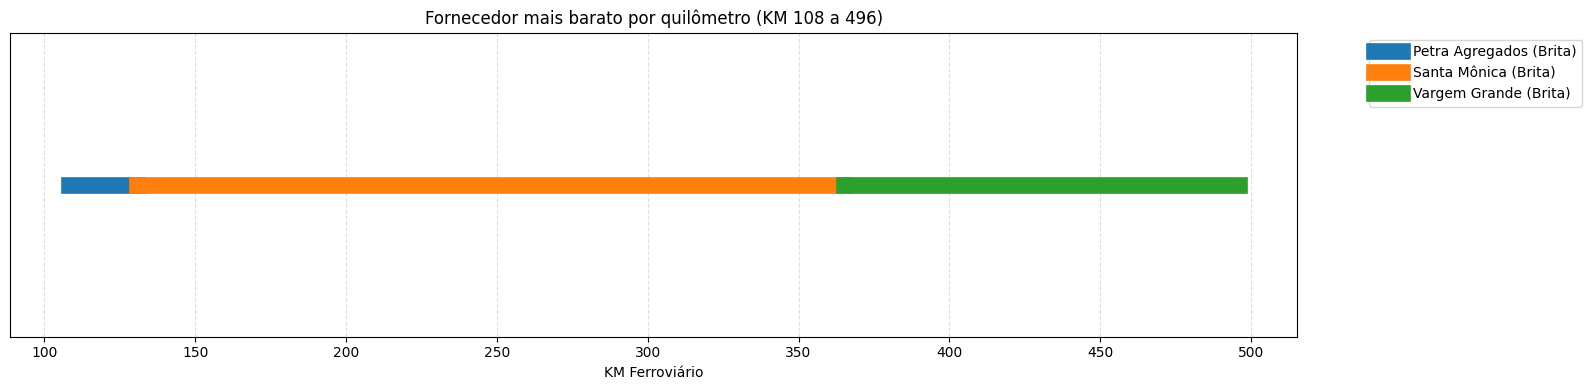

KeyboardInterrupt: Interrupted by user

In [16]:
# ============================================================
#        PROGRAMA 02 – Linear de Distribuição de Insumos
#     Alimentado automaticamente pelos dados do Programa 01
# ============================================================

import csv
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import List, Optional

# -----------------------------
# MODELOS
# -----------------------------

@dataclass
class Fornecedor:
    fonte: str
    material: str
    custo_aquisicao: float
    distancia_rodo: Optional[float]
    distancia_ferro: Optional[float]
    km_ferro: float

# -----------------------------
# ARQUIVOS DO PROGRAMA 01
# -----------------------------

DB_FORNEC = "fornecedores_db.csv"
DB_CUSTOS = "custos_transporte.csv"

# -----------------------------
# CARREGAMENTO DOS DADOS
# -----------------------------

def carregar_fornecedores():
    fornecedores = []
    with open(DB_FORNEC, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter=";")
        for row in reader:
            fornecedores.append(Fornecedor(
                fonte=row["Fonte"],
                material=row["Tipo de Material"],
                custo_aquisicao=float(row["Custo de Aquisição (R$/ton)"]),
                distancia_rodo=float(row["Distância Rodoviária (km)"]) if row["Distância Rodoviária (km)"] else None,
                distancia_ferro=float(row["Distância Ferroviária (km)"]) if row["Distância Ferroviária (km)"] else None,
                km_ferro=float(row["KM Ferroviária"])
            ))
    return fornecedores

def carregar_custos():
    with open(DB_CUSTOS, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter=";")
        row = next(reader)
        return float(row["Custo Rodoviário (R$/ton·km)"]), float(row["Custo Ferroviário (R$/ton·km)"])

# -----------------------------
# CÁLCULO DO CUSTO TOTAL POR KM
# -----------------------------

def distancia_ferro_total(f: Fornecedor, km: float):
    base = f.distancia_ferro if f.distancia_ferro is not None else 0
    return base + abs(f.km_ferro - km)

def custo_total_no_km(f: Fornecedor, km: float, c_rodo, c_ferro):
    dist_ferro = distancia_ferro_total(f, km)
    custo_ferro = dist_ferro * c_ferro
    custo_rodo = f.distancia_rodo * c_rodo if f.distancia_rodo is not None else 0
    return f.custo_aquisicao + custo_ferro + custo_rodo

# -----------------------------
# FUNÇÃO AUXILIAR PARA RANGE DECIMAL
# -----------------------------

def frange(start, stop, step):
    while start <= stop + 1e-9:
        yield round(start, 2)
        start = round(start + step, 2)

# -----------------------------
# GERAR LINEAR DE DISTRIBUIÇÃO
# -----------------------------

def gerar_linear(fornecedores_filtrados):
    fornecedores = fornecedores_filtrados
    c_rodo, c_ferro = carregar_custos()

    if not fornecedores:
        print("Nenhum fornecedor disponível para os insumos selecionados.")
        return

    linear = []
    km_inicio = 108.00
    km_fim = 496.00

    fornecedor_atual = None
    inicio_intervalo = km_inicio

    kms = list(frange(km_inicio, km_fim, 0.01))

    # Determinar fornecedor mais barato por km
    for km in kms:
        custos = [(f, custo_total_no_km(f, km, c_rodo, c_ferro)) for f in fornecedores]
        f_min, custo_min = min(custos, key=lambda x: x[1])

        if fornecedor_atual is None:
            fornecedor_atual = f_min

        if f_min != fornecedor_atual:
            linear.append((inicio_intervalo, km - 0.01, fornecedor_atual))
            fornecedor_atual = f_min
            inicio_intervalo = km

    linear.append((inicio_intervalo, km_fim, fornecedor_atual))

    # -----------------------------
    # CROQUI TEXTUAL
    # -----------------------------

    print("\n=== LINEAR DE DISTRIBUIÇÃO DE INSUMOS ===\n")

    for inicio, fim, f in linear:
        print(f"KM {inicio:.2f}–{fim:.2f} → {f.fonte} ({f.material})")

    print("\nCroqui gerado com sucesso.\n")

    # -----------------------------
    # GRÁFICO DE DOMINÂNCIA (SEM DIVISORES)
    # -----------------------------

    print("Gerando gráfico de dominância...")

    plt.figure(figsize=(16, 4))

    for inicio, fim, f in linear:
        plt.plot([inicio, fim], [1, 1], linewidth=12, label=f"{f.fonte} ({f.material})")

    # Remover duplicatas da legenda
    handles, labels = plt.gca().get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    plt.legend(unique.values(), unique.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.title("Fornecedor mais barato por quilômetro (KM 108 a 496)")
    plt.xlabel("KM Ferroviário")
    plt.yticks([])
    plt.grid(axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

# -----------------------------
# MENU INICIAL
# -----------------------------

def menu_principal():
    fornecedores = carregar_fornecedores()

    if not fornecedores:
        print("Nenhum fornecedor cadastrado no Programa 01.")
        return

    materiais = sorted(set(f.material for f in fornecedores))

    while True:
        print("\n=== PROGRAMA 02 – Linear de Distribuição de Insumos ===")
        print("Selecione os insumos que deseja considerar:\n")

        for i, m in enumerate(materiais, start=1):
            print(f"{i} - {m}")

        print("\n0 - Considerar TODOS os insumos")

        escolha = input("\nDigite os números dos insumos (ex: 1,3,5) ou 0 para todos: ").strip()

        if escolha == "0":
            fornecedores_filtrados = fornecedores
        else:
            indices = [int(x.strip()) for x in escolha.split(",")]
            materiais_escolhidos = {materiais[i - 1] for i in indices}
            fornecedores_filtrados = [f for f in fornecedores if f.material in materiais_escolhidos]

        gerar_linear(fornecedores_filtrados)

        repetir = input("\nGerar novo gráfico? (s/n): ").strip().lower()
        if repetir != "s":
            print("\nEncerrando o Programa 02...")
            break

# -----------------------------
# EXECUÇÃO
# -----------------------------

if __name__ == "__main__":
    menu_principal()
